# Experiment No. 10

## Title
**To create an OpenCV-Python program to smooth a given RGB/Grayscale image by a median filter**

## Objective
To smooth both grayscale and RGB images using a median filter.

## Mathematical Theory
Median filtering is a non-linear smoothing technique used to reduce noise, especially salt-and-pepper noise. Instead of averaging, it replaces the center pixel with the median value of the neighboring pixels.

For a $3 \times 3$ neighborhood, the output is:

$$
g(x,y)=\operatorname{median}\{f(x+m,y+n)\}
$$

for $m,n \in \{-1,0,1\}$

For RGB image:

$$
g(x,y,c)=\operatorname{median}\{f(x+m,y+n,c)\}
$$

Where:

- $f(x,y)$ = input pixel value  
- $g(x,y)$ = output pixel value  
- $c$ = color channel (Red, Green, Blue)

Median filtering is very effective in removing impulse noise while preserving edges better than linear smoothing filters.

## Instruments / Requirements
- Computer or Laptop
- Python
- OpenCV
- NumPy
- Matplotlib
- Input image: `demo_image.jpg`

## Procedure
1. Read the image using OpenCV.
2. If the image is color, convert it from BGR to RGB format.
3. Consider each $3 \times 3$ neighborhood.
4. Find the median of the neighborhood pixels.
5. For RGB image, apply the median operation separately on each color channel.
6. Store the filtered image.
7. Display the original and median filtered images.

## Output
- Original image (Grayscale/RGB)
- Smoothed image by median filter

## Result
The median filtered image shows reduced noise while preserving important edge structures. In RGB images, the median filter is applied channel-wise.

## Conclusion
Median filtering is a powerful non-linear smoothing technique that removes impulse noise effectively and preserves edges better than average and Gaussian filters.

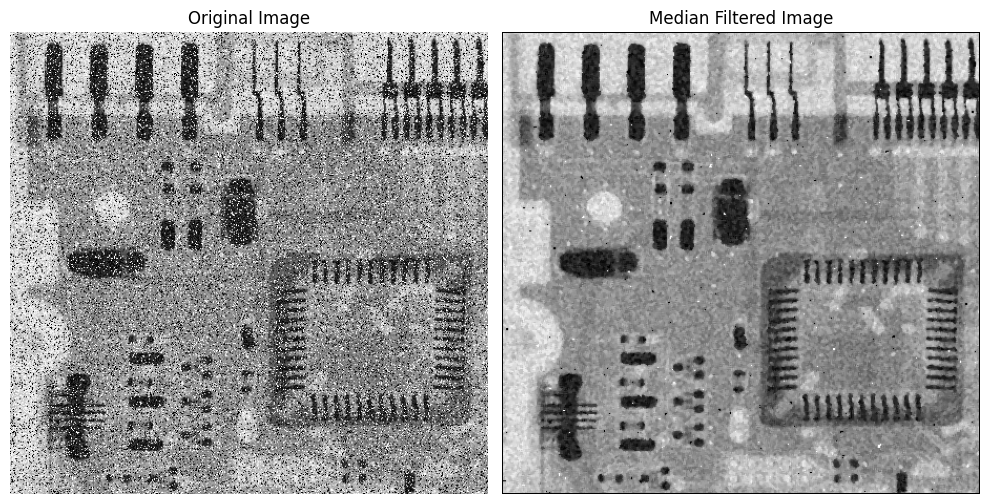

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread('Exp10_Demo.jpg')

# Check grayscale or color
if len(img.shape) == 2:
    h, w = img.shape
    filtered = np.zeros((h, w), dtype=np.uint8)

    for i in range(1, h - 1):
        for j in range(1, w - 1):
            window = []
            for m in range(-1, 2):
                for n in range(-1, 2):
                    window.append(img[i + m, j + n])
            filtered[i, j] = np.median(window)

    display_img = img
    display_filtered = filtered
    cmap = 'gray'

else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, c = img.shape
    filtered = np.zeros((h, w, c), dtype=np.uint8)

    for k in range(c):
        for i in range(1, h - 1):
            for j in range(1, w - 1):
                window = []
                for m in range(-1, 2):
                    for n in range(-1, 2):
                        window.append(img[i + m, j + n, k])
                filtered[i, j, k] = np.median(window)

    display_img = img
    display_filtered = filtered
    cmap = None

plt.figure(figsize=(10, 8))

plt.subplot(1, 2, 1)
plt.imshow(display_img, cmap=cmap)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(display_filtered, cmap=cmap)
plt.title("Median Filtered Image")
plt.axis("off")

plt.tight_layout()
plt.savefig('Exp10_Output.png')
plt.show()

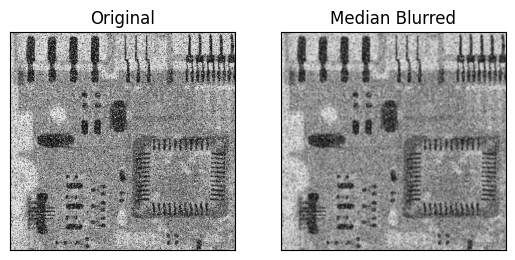

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('Exp10_Demo.jpg')

blur = cv2.GaussianBlur(img,(5,5),0)

plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(blur),plt.title('Median Blurred')
plt.xticks([]), plt.yticks([])
plt.show()